In [2]:
import pandas as pd
df_sci = pd.read_csv('science/Combined MPRA Summary Stats.csv',index_col=0)
df_zc = pd.read_csv('../ad_mpra_chen/outputs/allele_effects_for_plotting/annotated_20240719_comparative_HEK293T_alleleOnly.csv' ,index_col=0)[['rsid','Major','Minor','fdr','logFC_converted','center']]

df_zc['seq_id'] = df_zc.index

df_haploreg = pd.read_csv('indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_REFindex_catlas_with_all_peakfiles_variant_category_20260310_Bellenguez_AD_direction.csv',index_col=0)
df_zc = pd.merge(df_zc,df_haploreg[['GC_content',	'distance_to_tss',	'SNP_Function']],left_index=True,right_index=True)
df_overlap = df_zc[df_zc['rsid'].isin(df_sci.index)]


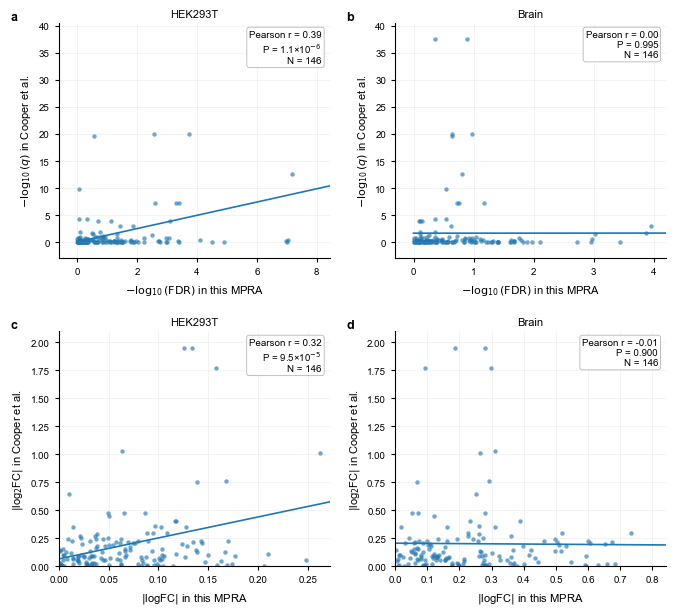

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# =========================
# Global plotting settings
# =========================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================
# Helper functions
# =========================
def fmt_p(p):
    if p < 1e-99:
        return "P < 1×10$^{-99}$"
    elif p < 1e-3:
        base, exp = f"{p:.1e}".split("e")
        return f"P = {float(base):.1f}×10$^{{{int(exp)}}}$"
    else:
        return f"P = {p:.3f}"

def load_zc_context(zc_path, haploreg_path):
    df_zc = pd.read_csv(zc_path, index_col=0)[
        ['rsid', 'Major', 'Minor', 'fdr', 'logFC_converted', 'center']
    ].copy()
    df_zc['seq_id'] = df_zc.index

    df_haploreg = pd.read_csv(haploreg_path, index_col=0)
    df_zc = pd.merge(
        df_zc,
        df_haploreg[['GC_content', 'distance_to_tss', 'SNP_Function']],
        left_index=True,
        right_index=True,
        how='left'
    )
    return df_zc

def merge_with_cooper(df_zc, df_sci):
    df_overlap = df_zc[df_zc['rsid'].isin(df_sci.index)].copy()

    df1 = df_sci.reset_index().copy()
    df2 = df_overlap.copy()

    merged_match = pd.merge(
        df1, df2,
        left_on=['rsID', 'A0', 'A1'],
        right_on=['rsid', 'Major', 'Minor'],
        how='inner'
    )

    merged_rev = pd.merge(
        df1, df2,
        left_on=['rsID', 'A1', 'A0'],
        right_on=['rsid', 'Major', 'Minor'],
        how='inner'
    )
    merged_rev['Log2.FC'] = -merged_rev['Log2.FC']

    merged_df = pd.concat([merged_match, merged_rev], axis=0)
    merged_df = merged_df.drop_duplicates(subset=['seq_id'])
    merged_df = merged_df.set_index('seq_id')
    return merged_df

def style_axes(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linewidth=0.4, alpha=0.25)
    ax.tick_params(width=0.8, length=3)

def add_stats_box(ax, x, y):
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    r, p_r = pearsonr(x, y)

    X = x.reshape(-1, 1)
    model = LinearRegression().fit(X, y)
    slope = float(model.coef_[0])
    intercept = float(model.intercept_)
    y_hat = model.predict(X)
    r2 = r2_score(y, y_hat)

    text = (
        f"Pearson r = {r:.2f}\n"
        f"{fmt_p(p_r)}\n"
       # f"$R^2$ = {r2:.2f}\n"
        f"N = {len(x)}"
    )

    ax.text(
        0.97, 0.97, text,
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=7,
        bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='0.7', lw=0.6, alpha=0.95)
    )

    return slope, intercept

def robust_limits(vals, lower_q=0.0, upper_q=0.995, pad_frac=0.06, min_span=1.0):
    vals = np.asarray(vals)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return 0, 1

    lo = np.quantile(vals, lower_q)
    hi = np.quantile(vals, upper_q)

    if hi <= lo:
        hi = lo + min_span

    pad = max((hi - lo) * pad_frac, min_span * 0.02)
    return lo - pad, hi + pad

def plot_sig_panel(ax, merged_df, panel_label, context_label):
    eps = 1e-300
    x = -np.log10(np.clip(merged_df["fdr"].to_numpy(dtype=float), eps, 1.0))
    y = -np.log10(np.clip(merged_df["q"].to_numpy(dtype=float), eps, 1.0))

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    ax.scatter(x, y, s=10, alpha=0.65, linewidth=0)

    slope, intercept = add_stats_box(ax, x, y)

    xmin, xmax = robust_limits(x, lower_q=0.0, upper_q=0.995, pad_frac=0.08, min_span=1.0)
    ymin, ymax = robust_limits(y, lower_q=0.0, upper_q=0.995, pad_frac=0.08, min_span=1.0)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    xx = np.linspace(max(0, xmin), xmax, 200)
    ax.plot(xx, slope * xx + intercept, linewidth=1.2)

    ax.set_xlabel(r"$-\log_{10}(\mathrm{FDR})$ in this MPRA")
    ax.set_ylabel(r"$-\log_{10}(q)$ in Cooper et al.")
    ax.set_title(context_label, pad=4)

    ax.text(
        -0.18, 1.05, panel_label,
        transform=ax.transAxes,
        fontsize=9, fontweight='bold',
        va='top', ha='left'
    )

    style_axes(ax)

def plot_effect_panel(ax, merged_df, panel_label, context_label):
    x = np.abs(merged_df["logFC_converted"].to_numpy(dtype=float))
    y = np.abs(merged_df["Log2.FC"].to_numpy(dtype=float))

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    ax.scatter(x, y, s=10, alpha=0.65, linewidth=0)

    slope, intercept = add_stats_box(ax, x, y)

    xmin, xmax = robust_limits(x, lower_q=0.0, upper_q=0.995, pad_frac=0.08, min_span=0.2)
    ymin, ymax = robust_limits(y, lower_q=0.0, upper_q=0.995, pad_frac=0.08, min_span=0.2)

    xmin = max(0, xmin)
    ymin = max(0, ymin)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    xx = np.linspace(xmin, xmax, 200)
    ax.plot(xx, slope * xx + intercept, linewidth=1.2)

    ax.set_xlabel(r"$|$logFC$|$ in this MPRA")
    ax.set_ylabel(r"$|$log$_2$FC$|$ in Cooper et al.")
    ax.set_title(context_label, pad=4)

    ax.text(
        -0.18, 1.05, panel_label,
        transform=ax.transAxes,
        fontsize=9, fontweight='bold',
        va='top', ha='left'
    )

    style_axes(ax)

# =========================
# Load data
# =========================
df_sci = pd.read_csv('science/Combined MPRA Summary Stats.csv', index_col=0)

haploreg_path = 'indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_REFindex_catlas_with_all_peakfiles_variant_category_20260310_Bellenguez_AD_direction.csv'

hek_path = '../ad_mpra_chen/outputs/allele_effects_for_plotting/annotated_20240719_comparative_HEK293T_alleleOnly.csv'
brain_path = '../ad_mpra_chen/outputs/allele_effects_for_plotting/annotated_20240616_comparative_BrainR1R2merged20240404_alleleOnly.csv'

df_hek = load_zc_context(hek_path, haploreg_path)
df_brain = load_zc_context(brain_path, haploreg_path)

merged_hek = merge_with_cooper(df_hek, df_sci)
merged_brain = merge_with_cooper(df_brain, df_sci)

# =========================
# Plot 2x2 figure
# =========================
fig, axes = plt.subplots(2, 2, figsize=(6.8, 6.2))

plot_sig_panel(axes[0, 0], merged_hek, "a", "HEK293T")
plot_sig_panel(axes[0, 1], merged_brain, "b", "Brain")
plot_effect_panel(axes[1, 0], merged_hek, "c", "HEK293T")
plot_effect_panel(axes[1, 1], merged_brain, "d", "Brain")

plt.tight_layout(w_pad=1.5, h_pad=1.8)

# only save PNG
plt.savefig("Cooper_comparison_4panel.png", dpi=600, bbox_inches="tight")
plt.show()